# Toronto Raptors: Statistical Analysis of Championship Decline (2018–2026)
### Python Regression & Correlation Analysis

**Tools:** Python (pandas, matplotlib, sklearn, statsmodels) · Google Colab  
**Dataset:** 8 seasons of Raptors team stats (2018–2026)

This project complements the Power BI dashboard with statistical analysis of what drove the Raptors' championship success in 2019 and subsequent decline. Covers Four Factors evolution, regression modeling, and correlation analysis against win percentage.

## Four Factors Framework

The "Four Factors" is an analytics framework developed by Dean Oliver (Basketball on Paper, 2004) that identifies the four statistical categories most correlated with winning:

1. **Shooting efficiency (eFG%)**
2. **Turnover rate (TOV%)**  
3. **Offensive rebounding (ORB%)**
4. **Free throw rate (FT/FGA)**

These metrics, split into offensive and defensive sides form the basis of the analysis alongside composite offensive and defensive ratings.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Data Loading
Load 8 seasons of Raptors team stats (2018–2026) from Google Sheets.
**Original data source:** Basketball-Reference.com (manually compiled).

In [2]:
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vSWM_H2FVZ6cWjqDUDkBQyV-7YWgbkjuufhIAykiDut9oGWI36HEM4WubrBxA0DwrppiDl9zO-_eely/pub?gid=1099310443&single=true&output=csv'

df = pd.read_csv(url)
df.head()

,season,g,record,win%,standing,off_rtg,def_rtg,net_rtg,srs,off_efg%,off_tov%,off_rb%,off_ft_rate,def_efg%,def_tov%,def_rb%,def_ft_rate
0,18-19,82,58-24,0.71,2,113.1,107.1,6.0,5.49,0.54,12.4,21.9,0.198,0.509,13.1,77.1,0.190
1,19-20,72,53-19,0.74,2,111.1,105.0,6.1,5.97,0.54,13.1,21.3,0.210,0.502,14.6,76.7,0.202
2,20-21,72,27-45,0.38,12,112.0,112.5,-0.5,-0.54,0.53,11.9,20.8,0.196,0.543,14.4,76.3,0.234
3,21-22,82,48-34,0.59,5,112.9,110.5,2.4,2.38,0.51,11.0,28.4,0.177,0.535,14.4,75.6,0.199
4,22-23,82,41-41,0.50,9,115.5,114.0,1.5,1.59,0.52,10.3,27.8,0.201,0.565,15.3,76.7,0.223


In [3]:
#Data Validaation
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

season          object
g                int64
record          object
win%           float64
standing         int64
off_rtg        float64
def_rtg        float64
net_rtg        float64
srs            float64
off_efg%       float64
off_tov%       float64
off_rb%        float64
off_ft_rate    float64
def_efg%       float64
def_tov%       float64
def_rb%        float64
def_ft_rate    float64
dtype: object
season         0
g              0
record         0
win%           0
standing       0
off_rtg        0
def_rtg        0
net_rtg        0
srs            0
off_efg%       0
off_tov%       0
off_rb%        0
off_ft_rate    0
def_efg%       0
def_tov%       0
def_rb%        0
def_ft_rate    0
dtype: int64
             g      win%  standing    off_rtg     def_rtg   net_rtg       srs  \
count   8.0000  8.000000   8.00000    8.00000    8.000000  8.000000  8.000000   
mean   79.5000  0.518750   7.25000  112.91250  111.962500  0.962500  0.848750   
std     4.6291  0.161195   4.26782    1.92609    4

In [4]:

display_df = df.copy()
display_df['off_efg%'] = display_df['off_efg%'] * 100
display_df['off_ft_rate'] = display_df['off_ft_rate'] * 100
display_df['def_efg%'] = display_df['def_efg%'] * 100
display_df['def_ft_rate'] = display_df['def_ft_rate'] * 100


## 3. Analysis

### Four Factors Evolution (Offensive VS Defensive) (2018–2026)
How have the four key performance metrics changed season by season?

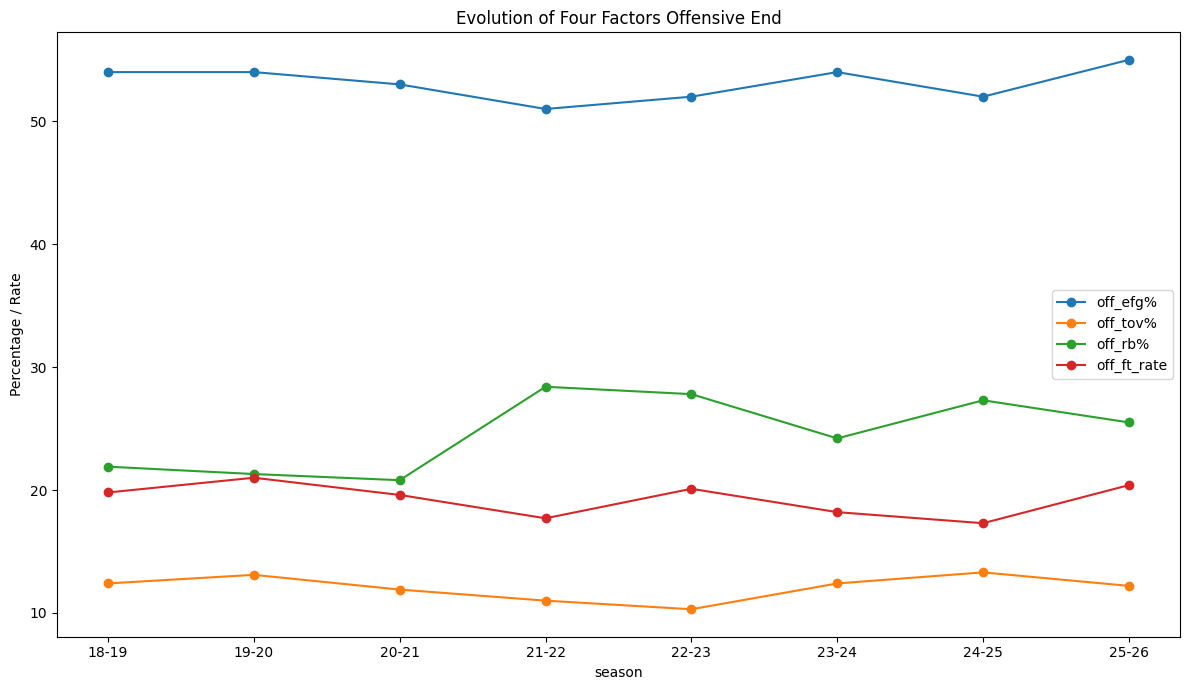

In [5]:
plot_df = display_df[['season', 'off_efg%', 'off_tov%', 'off_rb%', 'off_ft_rate']].set_index('season')

plot_df.plot(marker='o', figsize=(12, 7))
plt.title('Evolution of Four Factors Offensive End')
plt.xlabel('season')
plt.ylabel('Percentage / Rate')
plt.tight_layout()
plt.show()

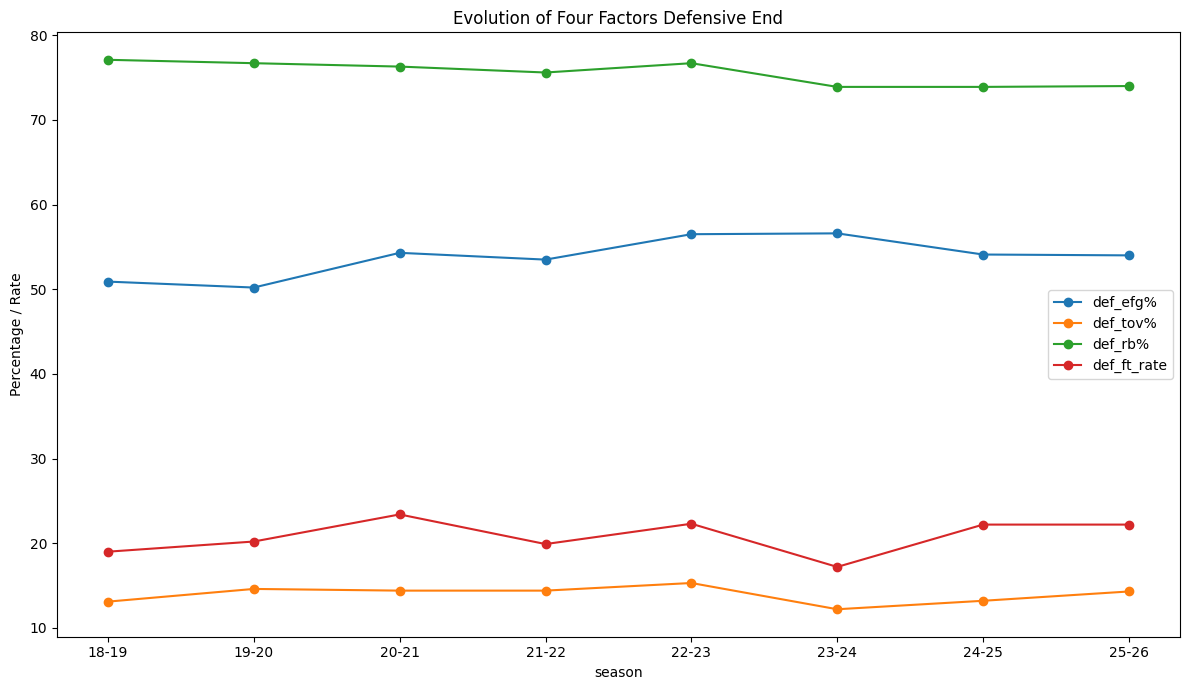

In [6]:
plot_df = display_df[['season', 'def_efg%', 'def_tov%', 'def_rb%', 'def_ft_rate']].set_index('season')

plot_df.plot(marker='o', figsize=(12, 7))
plt.title('Evolution of Four Factors Defensive End')
plt.xlabel('season')
plt.ylabel('Percentage / Rate')
plt.tight_layout()
plt.show()

**Finding:** Defensive metrics (especially def_eFG%) declined sharply after the 2019 championship season, with partial recovery in recent rebuild years. Offensive factors have been more variable across eras. FT rate has remained the most stable factor.

### Regression Analysis — What Predicts Wins?
Three models tested against win percentage:

- **Model 1:** Composite ratings (OFFrtg + DEFrtg)
- **Model 2:** Offensive Four Factors (eFG%, TOV%, ORB%, FT rate)
- **Model 3:** Defensive Four Factors (eFG%, TOV%, ORB%, FT rate)

In [7]:
features1 = ['off_rtg', 'def_rtg']
X = df[features1]
y = df['win%']

reg = LinearRegression()
reg.fit(X, y)

print(f'R-squared: {reg.score(X, y):.3f}')
print(f'Intercept: {reg.intercept_:.4f}\n')

print('Coefficients:')
pd.Series(reg.coef_, index=features1)

R-squared: 0.933
Intercept: 1.7397

Coefficients:


,0
off_rtg,0.024340
def_rtg,-0.035452


In [9]:
features2 = ['off_efg%', 'off_tov%', 'off_rb%', 'off_ft_rate']
X = df[features2]
y = df['win%']

reg = LinearRegression()
reg.fit(X, y)

print(f'R-squared: {reg.score(X, y):.3f}')
print(f'Intercept: {reg.intercept_:.4f}\n')

print('Coefficients:')
pd.Series(reg.coef_, index=features2)

R-squared: 0.439
Intercept: 0.1833

Coefficients:


,0
off_efg%,-5.417427
off_tov%,0.060756
off_rb%,0.009923
off_ft_rate,11.603859


In [11]:
features3 = ['def_efg%', 'def_tov%', 'def_rb%', 'def_ft_rate']
X = df[features3]
y = df['win%']

reg = LinearRegression()
reg.fit(X, y)

print(f'R-squared: {reg.score(X, y):.3f}')
print(f'Intercept: {reg.intercept_:.4f}\n')

print('Coefficients:')
pd.Series(reg.coef_, index=features3)

R-squared: 0.901
Intercept: 2.7356

Coefficients:


,0
def_efg%,-5.153841
def_tov%,0.102607
def_rb%,-0.001638
def_ft_rate,-3.617190


In [17]:
def adjusted_r2(r2, n, k):
    """n = sample size, k = number of predictors"""
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f"Model 1 Adjusted R²: {adjusted_r2(0.933, 8, 2):.3f}")
print(f"Model 2 Adjusted R²: {adjusted_r2(0.439, 8, 4):.3f}")
print(f"Model 3 Adjusted R²: {adjusted_r2(0.901, 8, 4):.3f}")

Model 1 Adjusted R²: 0.906
Model 2 Adjusted R²: -0.309
Model 3 Adjusted R²: 0.769


## Model Comparison Results

**Model 1: Composite Ratings**
- **R² = 0.933** — Explains 93.3% of win% variation
- **OffRtg (+0.023):** Each 1-point increase in offensive rating increases win% by ~2.3%
- **DefRtg (-0.036):** Each 1-point increase in defensive rating decreases win% by ~3.6%
- **Interpretation:** Defense has slightly larger impact than offense

**Model 2: Offensive Four Factors**
- **R² = 0.439** — Only explains 43.9% of variation
- **Coefficients show unexpected signs** (eFG% negative, TOV% positive)
- **Issue:** Offensive factors have weak individual correlations with winning for this team (see correlation analysis below). VIF analysis (next section) rules out multicollinearity as the cause.

**Model 3: Defensive Four Factors**
- **R² = 0.901** — Explains 90.1% of variation
- **def_eFG% is the strongest predictor** — opponent shooting efficiency dominates the model

**Conclusion:**
Defensive four factors (R²=0.901) explain wins almost as well as composite ratings (R²=0.933), while offensive four factors (R²=0.439) explain only half as much. Defense is the systematic driver of Raptors' performance — captured by four specific defensive metrics. Offense, in contrast, is too noisy to predict winning at the granular level.

In [13]:
# Check for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Model 1
X_vif = add_constant(df[features1])

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)



   feature          VIF
0    const  4267.247645
1  off_rtg     1.021486
2  def_rtg     1.021486


In [14]:
X_vif = add_constant(df[features2])

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

       feature          VIF
0        const  3743.990448
1     off_efg%     2.728193
2     off_tov%     2.132968
3      off_rb%     2.173837
4  off_ft_rate     2.587299


In [15]:
X_vif = add_constant(df[features3])

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

       feature          VIF
0        const  8539.108424
1     def_efg%     1.356456
2     def_tov%     2.817541
3      def_rb%     2.030363
4  def_ft_rate     2.075806


### VIF Interpretation

| Model | VIF Range | Diagnosis |
|-------|-----------|-----------|
| 1 (Composite) | 1.02 | No multicollinearity — predictors are essentially independent |
| 2 (Off 4F) | 2.13 – 2.73 | Low multicollinearity — factors are mostly independent |
| 3 (Def 4F) | 1.36 – 2.82 | Low multicollinearity — factors are mostly independent |

**Implication:** All VIF values are well below the conventional threshold of 5, indicating no multicollinearity issues. This rules out my initial hypothesis that Model 2's poor performance was due to redundant predictors. The actual explanation is that offensive four factors have inherently weaker correlations with winning than defensive factors for this team.

### Correlation Analysis — Metrics vs. Win%
Which individual stats correlate most strongly with winning?

def_rtg       -0.922149
def_efg%      -0.825910
def_rb%        0.620852
off_ft_rate    0.578890
def_tov%       0.381735
off_rb%       -0.227505
off_efg%       0.196858
off_rtg        0.150978
def_ft_rate   -0.124809
off_tov%       0.019119
dtype: float64


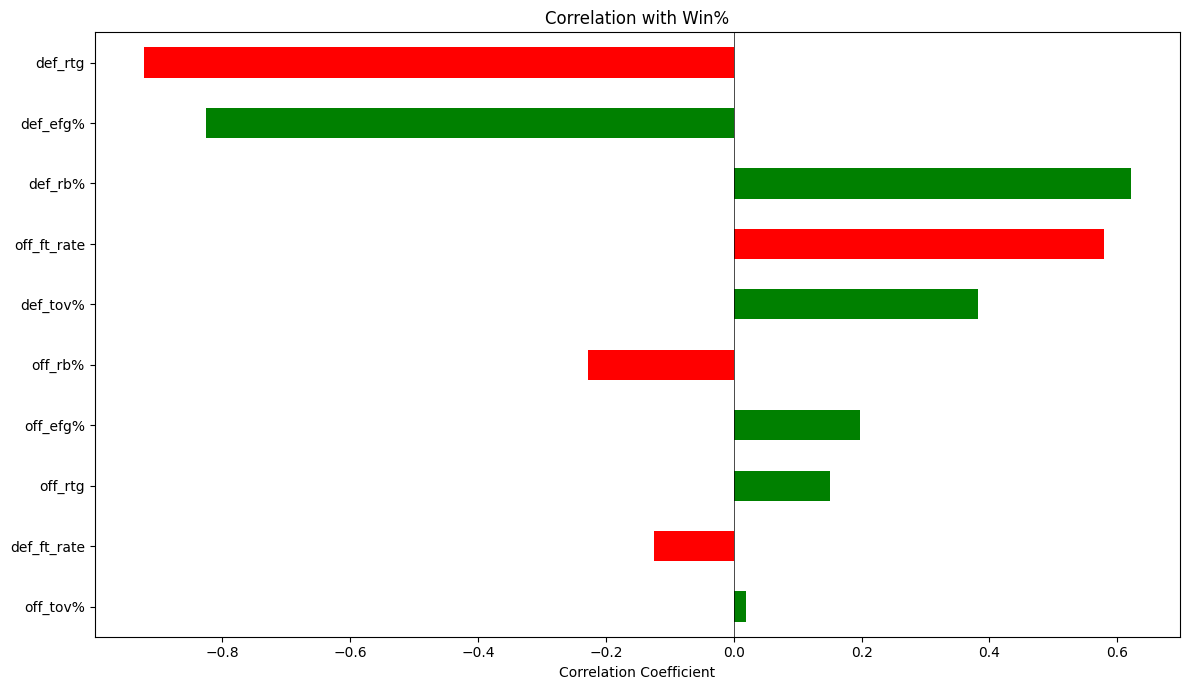

In [16]:
correlations = df[['off_rtg', 'def_rtg', 'off_efg%', 'off_tov%', 'off_rb%', 'off_ft_rate','def_efg%', 'def_tov%', 'def_rb%', 'def_ft_rate']].corrwith(df['win%'])
print(correlations.sort_values(key=abs, ascending=False))

plt.figure(figsize=(12, 7))
correlations_sorted = correlations.sort_values(key=abs)
correlations_sorted.plot(kind='barh', color=['red' if x < 0 else 'green' for x in correlations])
plt.title('Correlation with Win%')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


## Correlation Analysis Results

**Correlations with Win% (sorted by strength):**

1. **def_rtg (r = -0.922)** — DOMINANT PREDICTOR
   - Extremely strong negative correlation
   - As defense worsened (higher DefRtg), wins plummeted
   - This is the story: championship team had elite defense, rebuild teams don't

2. **def_efg% (r = -0.826)** — Strong negative
   - Higher opponent eFG% → fewer wins
   - Opponents miss more shots → better defense → more wins

3. **def_rb% (r = 0.620)** — Moderate positive
   - Higher defensive rebounding → more wins

4. **off_ft_rate (r = 0.579)** — Moderate positive
   - More free throws → more wins

5. **def_tov% (r = 0.382)** — Weak-to-moderate positive
   - More forced turnovers → more wins

6. **off_rb% (r = -0.228)** — Weak negative
   - Counterintuitive direction; likely small-sample noise

7. **off_efg% (r = 0.197)** — Weak positive
   - Offensive shooting efficiency barely predicts wins individually

8. **off_rtg (r = 0.151)** — Very weak
   - Composite offensive rating has almost no effect

9. **def_ft_rate (r = -0.125)** — Very weak
   - Opponent free throw rate has minimal effect

10. **off_tov% (r = 0.019)** — Essentially zero
    - Offensive turnover rate has no effect on winning

**Key Pattern:** Five of the top six correlations are defensive metrics. Offense barely registers as a predictor of winning at the metric level — even composite OffRtg has only r = 0.151. This reinforces the defense-driven story.

---
## 4. Summary

**Key Findings:**
- Defensive rating (DefRtg) is by far the strongest predictor of Raptors win% (r = -0.922)
- Composite ratings (OFFrtg + DEFrtg) explain 93% of win variance — a reliable model
- Defensive Four Factors explain 90% of win variance, while Offensive Four Factors only explain 44%
- VIF analysis ruled out multicollinearity as the cause — offensive factors genuinely have weaker individual correlations with winning
- The championship era was defined by elite defense; current rebuild teams have not matched it

**Takeaway:**  
For the Raptors to return to contention, defensive improvement is the clearest statistical lever. Offensive efficiency, while important, has shown weak correlation with winning during this period.

**The Championship-to-Rebuild Story:**
- 2018-19: DefRtg = 107.1 (elite) → 58 wins
- 2023-24: DefRtg = 118.8 (terrible) → 25 wins
- **11.7 point increase in DefRtg = 33 fewer wins**

### Why Defensive Factors Predict Better Than Offensive Factors

The dramatic gap between Model 2 (R²=0.439) and Model 3 (R²=0.901) is the key analytical finding. VIF analysis ruled out multicollinearity as the cause — the offensive factors are not redundant. Instead, they genuinely have weaker individual correlations with winning.

**Defensive performance is systematic.** When the Raptors had a championship defense in 2018-19, all four defensive factors aligned (low opponent eFG%, strong defensive rebounding, etc.). When defense collapsed in 2023-24, all four factors deteriorated together. Defense is a coordinated team effort that shows up in every defensive metric.

**Offensive performance is noisy.** Individual offensive factors (eFG%, TOV%, ORB%, FT rate) trade off against each other (e.g., teams that crash the offensive glass forfeit transition defense). The Raptors' offense had multiple "shapes" across the 8 seasons — Kawhi-led isolation in 2019, Siakam-led ball movement in 2020-22, Barnes-led rebuild in 2024-25 — each emphasizing different factors. This makes the offensive Four Factors model unreliable as a predictor of winning.

**Implication:** Composite OffRtg/DefRtg captures aggregate offensive performance well (Model 1 R²=0.933), but the granular offensive factors don't predict wins individually. Defense, by contrast, is granularly predictable.

## Limitations

**Sample Size:**
This analysis uses 8 seasons (2018-2026), which limits statistical power. With only 8 observations:
- Regression coefficients have wide confidence intervals
- Correlation estimates may be unstable
- Adjusted R² values for the four-factor models drop sharply due to the predictor count, reflecting the small-sample penalty

**Why This Timeframe:**
We prioritize narrative coherence over sample size. The 8-season window captures a complete arc: championship → decline → rebuild under consistent modern NBA rules. Extending to 20+ years would include different basketball eras and dilute the specific story being analyzed.

**Single-Team Scope:**
Findings reflect the Raptors' specific roster transitions and may not generalize to other teams or time periods.

